# CIFAR-10 Image Classification in TensorFlow
Image classification is a fundamental task in computer vision, and the CIFAR-10 dataset is a popular benchmark for evaluating image classification models. In this tutorial, we will build a simple convolutional neural network (CNN) using TensorFlow to classify images from the CIFAR-10 dataset.


In [2]:
# type: ignore
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

I0000 00:00:1789556808.939649  106185 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789556809.136352  106185 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789556815.047597  106185 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Load CIFAR-10 Dataset
- Train set: 50,000 images
- Test set: 10,000 images
- Classes: 10 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)

In [4]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

Preprocessing the Data
- Normalization scales pixel values to the range [0,1] for better convergence during training.
- One-hot encoding converts class labels into a binary matrix representation, which is suitable for multi-class classification.

In [5]:
# Normalize pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Visualize Sample Images
- Display a 4x4 grid of sample images from the training set along with their corresponding class labels to get an idea of the dataset's content.

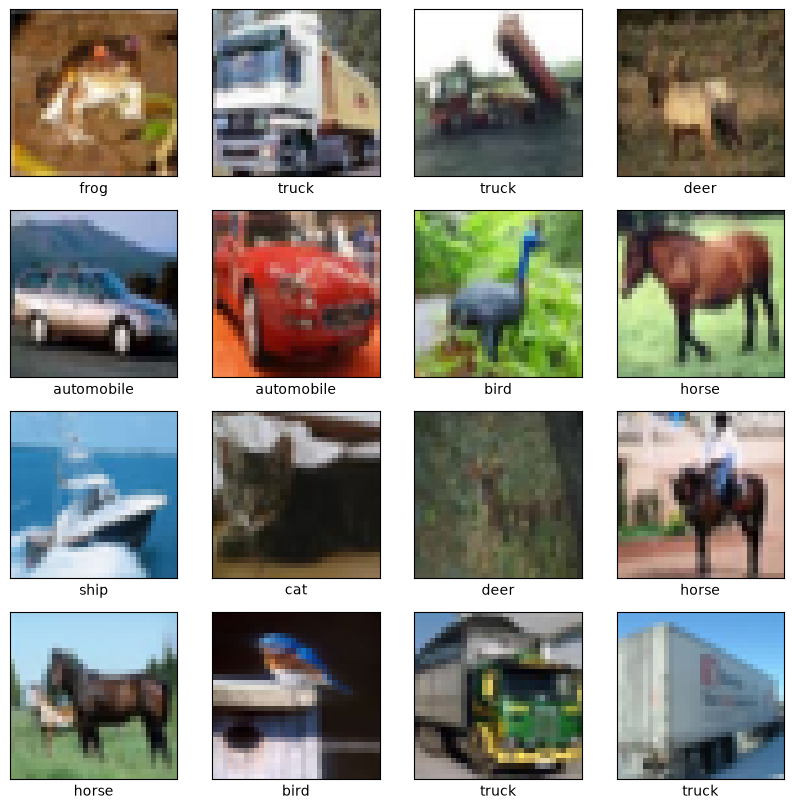

In [6]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[np.argmax(y_train[i])])

plt.show()

Build the CNN Model
- Construct a simple CNN architecture with convolutional layers, pooling layers, and fully connected layers.
- Convolutional layers extract features from the input images, while pooling layers reduce the spatial dimensions and help prevent overfitting. Fully connected layers perform the final classification based on the extracted features.
- MaxPooling is used to downsample the feature maps, and ReLU activation functions introduce non-linearity to the model.
- Dropout is applied to prevent overfitting by randomly setting a fraction of input units to zero during training.
- Softmax activation is used in the output layer to produce a probability distribution over the 10 classes.

In [7]:
model = models.Sequential()

# Build the CNN model
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

# Add more convolutional layers
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

# Add even more convolutional layers
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

# Flatten the output and add fully connected layers
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

E0000 00:00:1789556848.929615  106185 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Compile the Model
- Ontimizer: Adam (Adaptive Moment Estimation) optimizer is used for efficient training.
- Loss Function: Categorical cross-entropy is used as the loss function for multi-class classification
- Metrics: Accuracy is used to evaluate the model's performance during training and testing.

In [8]:
model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,341,226 (5.12 MB)

 Trainable params: 1,341,226 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

Train the Model
- Epochs: The number of complete passes through the training dataset.
- Batch Size: The number of samples processed before the model is updated.
- Validation Split: A fraction of the training data is used for validation to monitor the model's performance on unseen data during training.


In [9]:
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/30


W0000 00:00:1789556868.441421  106185 cpu_allocator_impl.cc:82] Allocation of 491520000 exceeds 10% of free system memory.


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.3568 - loss: 1.7269

W0000 00:00:1789557099.145675  106185 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


625/625 ━━━━━━━━━━━━━━━━━━━━ 243s 378ms/step - accuracy: 0.3568 - loss: 1.7269 - val_accuracy: 0.4977 - val_loss: 1.3736
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 256s 410ms/step - accuracy: 0.5299 - loss: 1.2932 - val_accuracy: 0.5758 - val_loss: 1.1888
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 245s 392ms/step - accuracy: 0.6105 - loss: 1.0963 - val_accuracy: 0.6802 - val_loss: 0.9194
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 248s 397ms/step - accuracy: 0.6605 - loss: 0.9556 - val_accuracy: 0.6875 - val_loss: 0.8751
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 232s 371ms/step - accuracy: 0.6940 - loss: 0.8661 - val_accuracy: 0.7149 - val_loss: 0.8156
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 212s 339ms/step - accuracy: 0.7137 - loss: 0.8075 - val_accuracy: 0.7393 - val_loss: 0.7435
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.7354 - loss: 0.7538 - val_accuracy: 0.7460 - val_loss: 0.7239
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 306ms/step - accuracy: 0.7528 - loss: 0.70

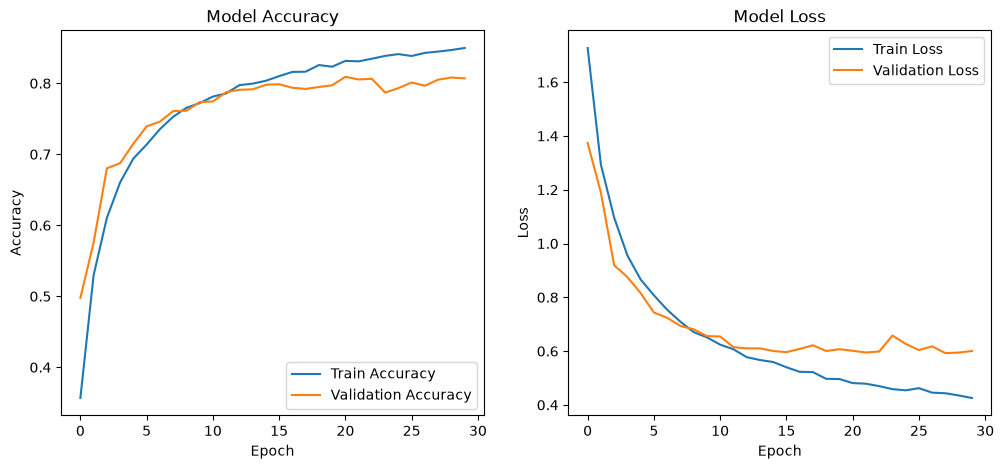

In [10]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step


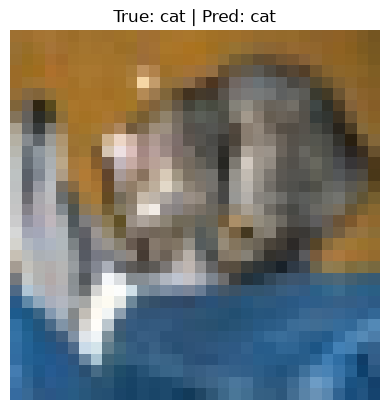

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


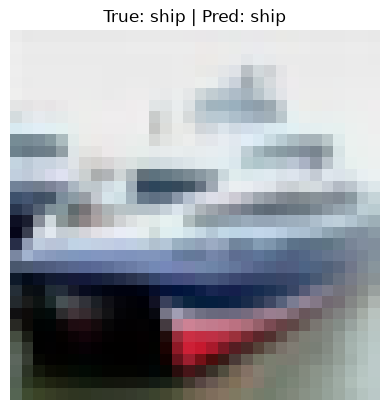

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


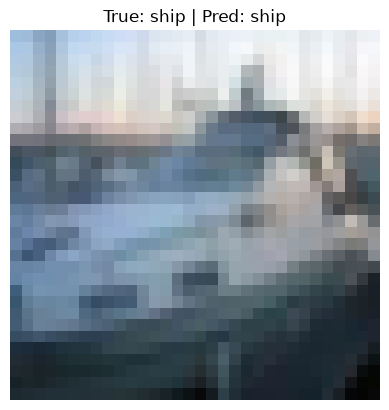

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


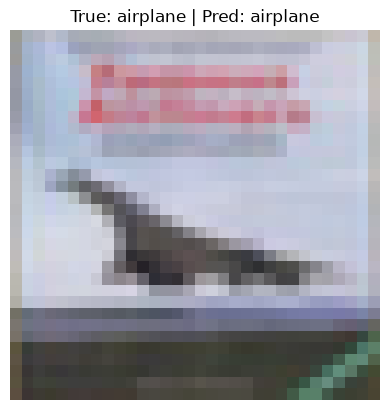

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


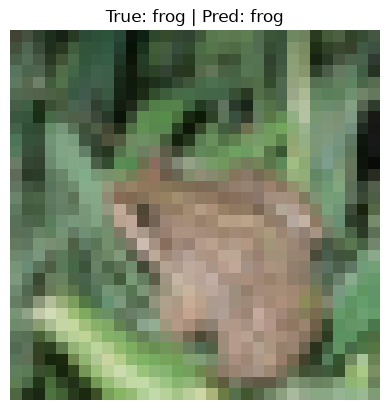

In [11]:
def plot_predictions(index):
    img = X_test[index]
    true_label = class_names[np.argmax(y_test[index])]
    pred_probs = model.predict(np.expand_dims(img, axis=0))
    pred_label = class_names[np.argmax(pred_probs)]
    
    plt.imshow(img)
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')
    plt.show()


for i in range(5):
    plot_predictions(i)

In [12]:
# Save the model
model.save('cifar10_cnn_model.h5')
